<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Advanced Machine Learning</p>

<p style="text-align: center;"> Course code: 203238427 </p>

<p style="text-align: center;"> Group: 01 </p>

<p style="text-align: center;"> Phase 4 - Time series</p>

<p style="text-align: center;">  Presented by: Jeronimo Ramos Ruiz</p>

<p style="text-align: center;">  Tutor: Rafael Gaitán Ospina </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, April 2026 </p>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


# Load dataset

For the development of this work, the data set containing the monthly milk production per cow from January 1962 to December 1975 was selected. It is assumed that the unit of measurement corresponds to the liters measured after one day of production.

In [35]:
# We load the data from the GitHub repository to avoid problems
# with importing it if working with a Colab kernel

path = 'https://raw.githubusercontent.com/Jero2110/Advanced-ML_Phase-04/refs/heads/main/analysis/data/monthly-milk-production-pounds-p(in).csv'


df = pd.read_csv(path, parse_dates=['Month'], index_col='Month')
df = df.rename(columns={'Monthly milk production: pounds per cow. Jan 62 ? Dec 75': 'Milk_production'})

df.tail()


,Milk_production
Month,
1975-10,827.0
1975-11,797.0
1975-12,843.0
NaN,NaN
Monthly milk production: pounds per cow. Jan 62 ? Dec 75,NaN


In many cases, when importing data from a CSV file, some records in the last few rows may not be relevant for analysis. Therefore, they will be removed from the working data frame.

In [43]:
df_clean = df.dropna()

df_clean.index = pd.to_datetime(df_clean.index)

df_clean.tail()

,Milk_production
Month,
1975-08-01,858.0
1975-09-01,817.0
1975-10-01,827.0
1975-11-01,797.0
1975-12-01,843.0


Once these rows have been removed, we will proceed to identify possible missing data and outliers with the help of the boxplot:

In [44]:
# First we will identify the null values

rows = df_clean.shape[0]
null_rows = df_clean.isna().sum()

print('---'*30)
print(f'The data set has {rows} rows, of which {null_rows} have null values')
print('---'*30)

------------------------------------------------------------------------------------------
The data set has 168 rows, of which Milk_production    0
dtype: int64 have null values
------------------------------------------------------------------------------------------


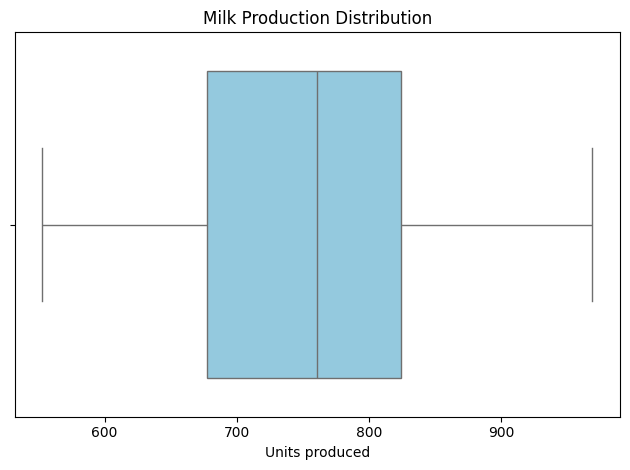

In [49]:
plt.plot(figsize=(10, 10))

# Box plot (to see outliers and distribution)
sns.boxplot(x=df_clean['Milk_production'], color='skyblue')
plt.title('Milk Production Distribution')
plt.xlabel('Units produced')

plt.tight_layout()
plt.show()

As can be seen in the box plot, there do not appear to be any outliers within the selected dataset, as they all remain within the interquartile range. Therefore, we can continue with the analysis with the certainty that we have no outliers.

However, since the data covers all 12 months of each year, the records will be counted by year to identify any missing values ​​that need to be corrected.

In [47]:
records_per_year = df_clean.index.year.value_counts().sort_index()

print('---'*30)
print(f'{records_per_year}')
print('---'*30)

------------------------------------------------------------------------------------------
Month
1962    12
1963    12
1964    12
1965    12
1966    12
1967    12
1968    12
1969    12
1970    12
1971    12
1972    12
1973    12
1974    12
1975    12
Name: count, dtype: int64
------------------------------------------------------------------------------------------


As can be seen in the table above, there does not appear to be any missing data, as all years of study seem to contain information for each of the months of study.

# Step 1

Now that we know the information is clean, we will proceed to identify, using a line graph, the possible presence of trend and seasonality.

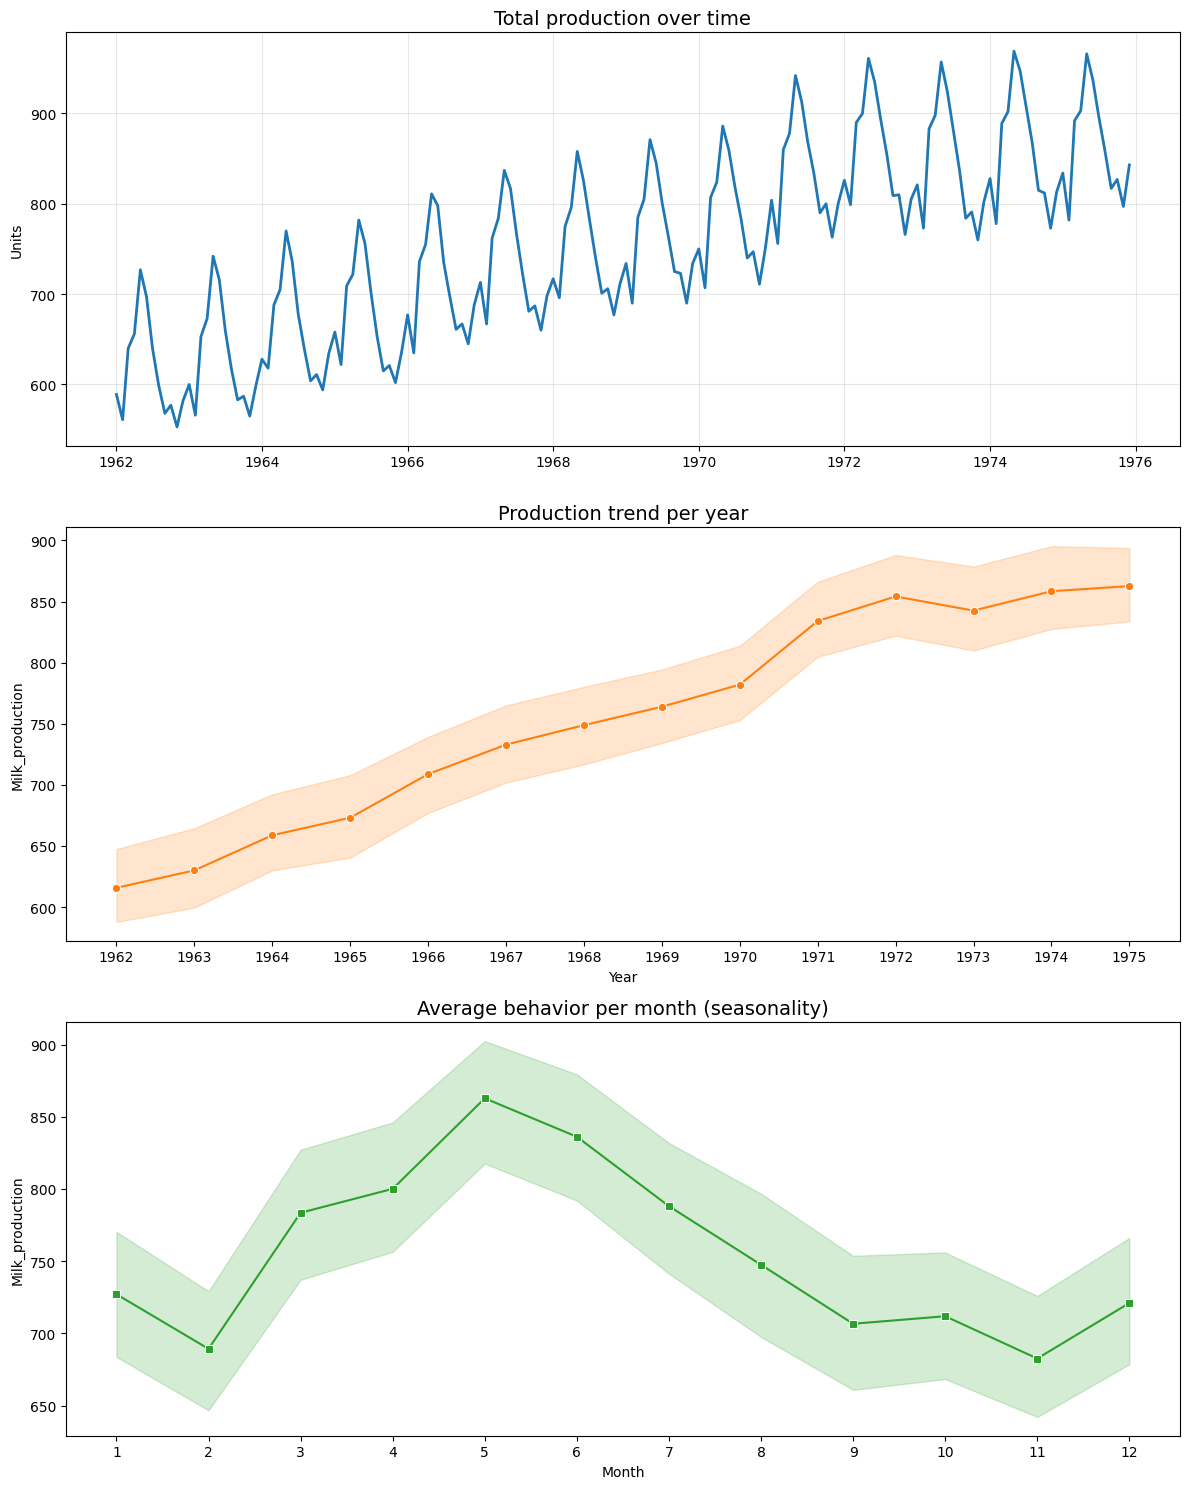

In [55]:
# First wwe create the columns with the information of the day, month and year 
# Crear las nuevas columnas
df_clean.loc[:, 'Year'] = df_clean.index.year
df_clean.loc[:,'Month'] = df_clean.index.month

# Line graph (to visualize monthly production over time in different times)
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Chart 1: Complete time series (solid line)
axes[0].plot(df_clean.index, df_clean['Milk_production'], color='tab:blue', linewidth=2)
axes[0].set_title('Total production over time', fontsize=14)
axes[0].set_ylabel('Units')
axes[0].grid(True, alpha=0.3)

# Chart 2: Variation by Year (Using the 'Year' column)
sns.lineplot(data=df_clean, x='Year', y='Milk_production', ax=axes[1], color='tab:orange', marker='o')
axes[1].set_title('Production trend per year', fontsize=14)
axes[1].set_xticks(df_clean['Year'].unique())

# Chart 3: Seasonality by month (using the 'Month' column)
sns.lineplot(data=df_clean, x='Month', y='Milk_production', ax=axes[2], color='tab:green', marker='s')
axes[2].set_title('Average behavior per month (seasonality)', fontsize=14)
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


In the graphs above we can observe the normal behavior of the data series (first graph with blue lines), the possible trend of the data over the years (second graph with orange lines) and the possible presence of temporality through the months of study (last graph in green).

The first graph shows a clear upward trend in the data, which is confirmed in the second. This indicates that monthly milk production is increasing over time, either due to an increase in the number of cattle or improvements in milk extraction and feeding technologies. On the other hand, a recurring pattern is observed in the middle of the year, as confirmed by the third graph. It appears that milk production peaks in May and then declines throughout the year. This could be related to the seasons in some countries, where cold weather influences food production and vegetation, as well as the ability of cows to produce milk, since they use all their energy to survive the cold. Meanwhile, between April and July, the weather is suitable for food production and there is not as much stress to affect the animals' milk production.

# Step 2

# Step 3

# Step 4

# Step 5

# References